# 1. Project Introduction

**Business Objective**: To segment the customer base using an adapted B2B SaaS RFM (Recency, Frequency, Monetary) methodology.

**Why RFM for SaaS?**: Traditional e-commerce RFM relies on transactional checkout history (e.g. bought a pair of shoes last week). In a recurring revenue model (SaaS), "transactions" are automated via subscriptions. Therefore, we adapt RFM to measure **Product Engagement** (Recency and Frequency of usage) combined with **Account Value** (Current MRR) to identify our Champions, At-Risk high-value accounts, and expansion targets.

# 2. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (12, 6)

current_dir = Path.cwd()
PROJECT_ROOT = current_dir.parent if current_dir.name == 'notebooks' else current_dir
DATA_CLEANED_DIR = PROJECT_ROOT / 'data' / 'cleaned'

print(f"Project Root: {PROJECT_ROOT}")

Project Root: C:\Users\shaikh raheem\OneDrive\Desktop\B2B SaaS Customer Cohort & Retention Analytics Platform


# 3. Load & Validate Data

In [2]:
accounts_df = pd.read_csv(DATA_CLEANED_DIR / 'accounts.csv')
subscriptions_df = pd.read_csv(DATA_CLEANED_DIR / 'subscriptions.csv')
feature_usage_df = pd.read_csv(DATA_CLEANED_DIR / 'feature_usage.csv')
support_tickets_df = pd.read_csv(DATA_CLEANED_DIR / 'support_tickets.csv')

feature_usage_df['usage_date'] = pd.to_datetime(feature_usage_df['usage_date'])

print(f"Accounts: {len(accounts_df):,}")
print(f"Usage Events: {len(feature_usage_df):,}")

Accounts: 500
Usage Events: 25,000


# 4. Define RFM Methodology (B2B SaaS Adaptation)

**Critical Data Limitation**: Because B2B SaaS revenue is subscription-based, we lack intermittent invoice-level transactional data. Summing "transaction revenue" across usage events would absurdly double-count subscription value.

- **Reference Date**: The maximum `usage_date` observed across all customers in the entire dataset. (Using today's system date would make the analysis non-reproducible over time).
- **Recency (R)**: The number of days between the Reference Date and the customer's *most recent* product usage date. (Lower days = Better Recency).
- **Frequency (F)**: The total count of *unique active usage days* logged by the customer over their lifetime. (Higher count = Better Frequency).
- **Monetary (M)**: The *Current Active MRR* (Monthly Recurring Revenue) attached to the account. (Higher MRR = Better Monetary).

In [3]:
reference_date = feature_usage_df['usage_date'].max()
print(f"Reference Date for Recency calculation: {reference_date.strftime('%Y-%m-%d')}")

Reference Date for Recency calculation: 2024-12-31


# 5. Create Customer-Level RFM Dataset
Grain: `1 ROW = 1 CUSTOMER`

In [4]:
# Map usage to account_id via subscriptions
usage_with_acct = feature_usage_df.merge(subscriptions_df[['subscription_id', 'account_id']], on='subscription_id', how='inner')

# Calculate Recency and Frequency per Account
rf_agg = usage_with_acct.groupby('account_id').agg(
    last_usage_date=('usage_date', 'max'),
    frequency=('usage_date', 'nunique') # Unique active days
).reset_index()

rf_agg['recency'] = (reference_date - rf_agg['last_usage_date']).dt.days

# Calculate Monetary per Account
# We only evaluate Active MRR for the RFM model
active_subs = subscriptions_df[subscriptions_df['churn_flag'] == False]
m_agg = active_subs.groupby('account_id')['mrr_amount'].sum().reset_index()
m_agg.rename(columns={'mrr_amount': 'monetary'}, inplace=True)

# Merge to Accounts (Only active accounts for RFM targeting)
active_accounts = accounts_df[accounts_df['churn_flag'] == False].copy()
rfm_df = active_accounts[['account_id', 'plan_tier', 'industry', 'seats']].merge(rf_agg[['account_id', 'recency', 'frequency']], on='account_id', how='left')
rfm_df = rfm_df.merge(m_agg, on='account_id', how='left')

# Handle accounts with zero usage or zero MRR
# If no usage, set recency to an arbitrarily high number (e.g. 999) and frequency to 0
rfm_df['recency'] = rfm_df['recency'].fillna(999)
rfm_df['frequency'] = rfm_df['frequency'].fillna(0)
rfm_df['monetary'] = rfm_df['monetary'].fillna(0)

assert rfm_df['account_id'].is_unique, "RFM Dataset Grain is duplicated!"
print(f"Active Customer RFM Dataset created: {len(rfm_df)} accounts.")

Active Customer RFM Dataset created: 390 accounts.


# 6. RFM Distribution Analysis

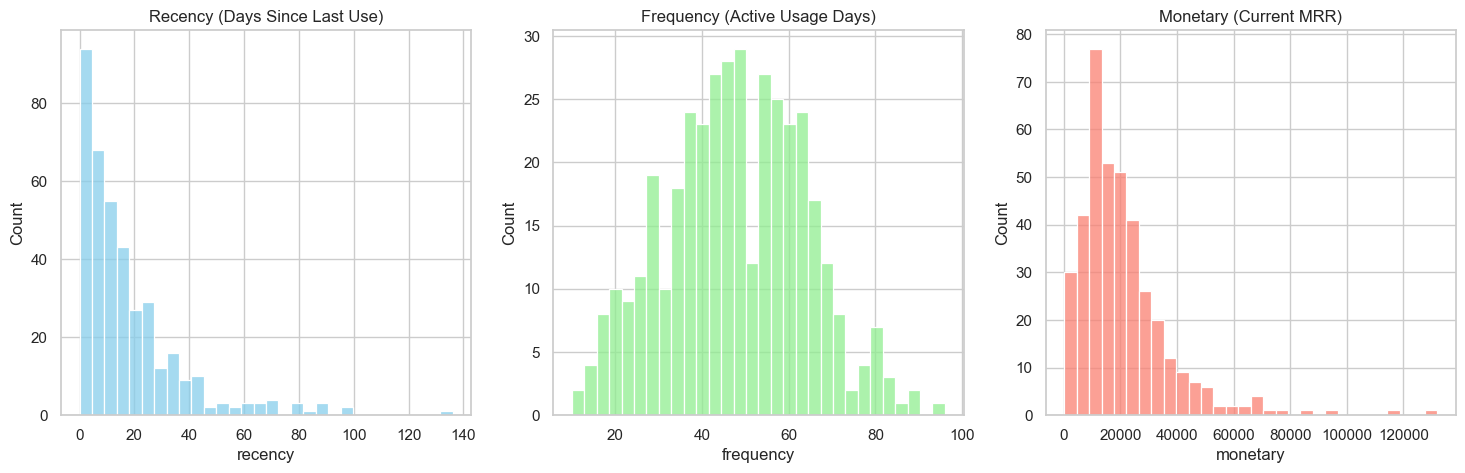

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(rfm_df[rfm_df['recency'] < 999]['recency'], bins=30, ax=axes[0], color='skyblue')
axes[0].set_title('Recency (Days Since Last Use)')
sns.histplot(rfm_df['frequency'], bins=30, ax=axes[1], color='lightgreen')
axes[1].set_title('Frequency (Active Usage Days)')
sns.histplot(rfm_df['monetary'], bins=30, ax=axes[2], color='salmon')
axes[2].set_title('Monetary (Current MRR)')
plt.show()

**Observation**: The distributions show right-skew (especially in Monetary and Frequency), which is standard for B2B SaaS where a subset of Enterprise accounts drives outsized value and usage.

# 7. RFM Scoring

We assign scores from 1 (Worst) to 4 (Best) using quartiles. 
- **R_Score**: Lower Recency gets a higher score (4 is recently active).
- **F_Score**: Higher Frequency gets a higher score (4 is highly frequent).
- **M_Score**: Higher Monetary gets a higher score (4 is highest MRR).

*(Using rank-based `qcut` to safely handle ties in skewed distributions).* 

In [6]:
def safe_qcut(series, q, labels):
    return pd.qcut(series.rank(method='first'), q=q, labels=labels)

rfm_df['R_Score'] = safe_qcut(rfm_df['recency'], 4, labels=[4, 3, 2, 1]).astype(int) # Reverse labels: smaller recency = higher rank (1st quartile gets 4)
rfm_df['F_Score'] = safe_qcut(rfm_df['frequency'], 4, labels=[1, 2, 3, 4]).astype(int)
rfm_df['M_Score'] = safe_qcut(rfm_df['monetary'], 4, labels=[1, 2, 3, 4]).astype(int)

rfm_df['RFM_Concat'] = rfm_df['R_Score'].astype(str) + rfm_df['F_Score'].astype(str) + rfm_df['M_Score'].astype(str)

display(rfm_df[['account_id', 'recency', 'frequency', 'monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Concat']].head())

,account_id,recency,frequency,monetary,R_Score,F_Score,M_Score,RFM_Concat
0,A-2e4581,21,55,12603,2,3,2,232
1,A-0a282f,9,80,13311,3,4,2,342
2,A-1f0ac7,20,40,9275,2,2,1,221
3,A-1b9609,41,44,16614,1,2,2,122
4,A-a0ca4e,14,39,16633,2,2,2,222


# 8. RFM Composite Score
Calculating a simple sum of the components. Max score = 12, Min score = 3.

In [7]:
rfm_df['RFM_Sum'] = rfm_df['R_Score'] + rfm_df['F_Score'] + rfm_df['M_Score']

# 9. RFM Customer Segments

We assign descriptive business segments based on specific score permutations rather than relying solely on the sum, which can mask the nuances of SaaS retention risks.

- **Champions**: High everything (4s and 3s across the board).
- **At Risk (High Value)**: High Monetary, but poor Recency/Frequency (M >= 3, R <= 2, F <= 2).
- **Loyal / Engaged**: Strong usage but not necessarily top tier MRR (R >= 3, F >= 3, M <= 2).
- **Recent / Low Engagement**: New or inactive (R >= 3, F <= 2).
- **Needs Attention**: Mediocre scores across the board.
- **Lost / Low Value**: Bottom tier in everything (1s and 2s).

In [8]:
def assign_segment(row):
    if row['R_Score'] >= 3 and row['F_Score'] >= 3 and row['M_Score'] >= 3:
        return 'Champions'
    elif row['M_Score'] >= 3 and (row['R_Score'] <= 2 or row['F_Score'] <= 2):
        return 'At Risk (High Value)'
    elif row['R_Score'] >= 3 and row['F_Score'] >= 3 and row['M_Score'] <= 2:
        return 'Loyal / Engaged'
    elif row['R_Score'] >= 3 and row['F_Score'] <= 2:
        return 'Recent / Low Engagement'
    elif row['R_Score'] <= 2 and row['F_Score'] <= 2 and row['M_Score'] <= 2:
        return 'Lost Cause / Low Value'
    else:
        return 'Needs Attention'

rfm_df['Segment'] = rfm_df.apply(assign_segment, axis=1)

# 10. Segment Distribution
How does the customer base distribute across these RFM profiles?

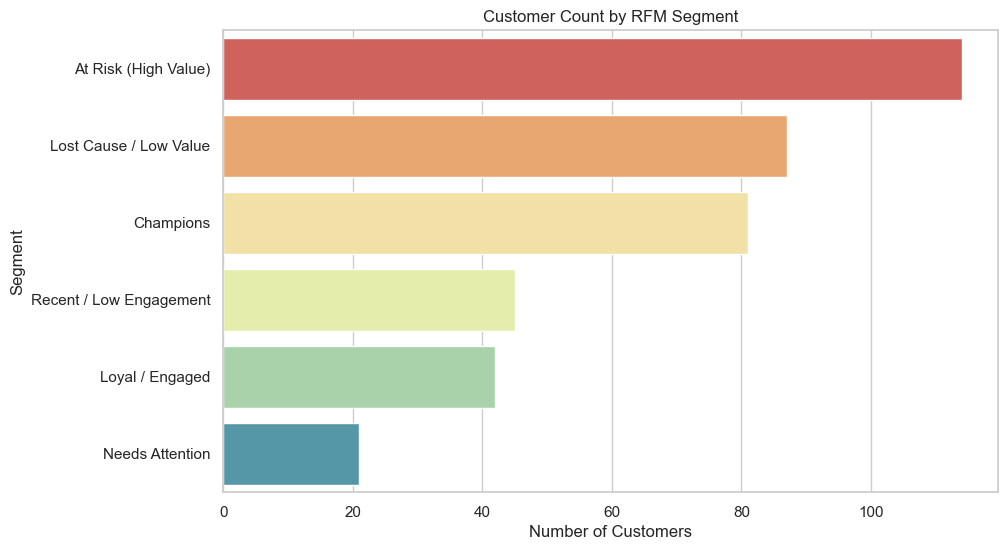

In [9]:
segment_counts = rfm_df['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Customer_Count']

plt.figure(figsize=(10, 6))
sns.barplot(data=segment_counts, y='Segment', x='Customer_Count', palette='Spectral')
plt.title('Customer Count by RFM Segment')
plt.xlabel('Number of Customers')
plt.ylabel('Segment')
plt.show()

# 11. Segment Revenue Analysis
Which segments carry the most MRR?

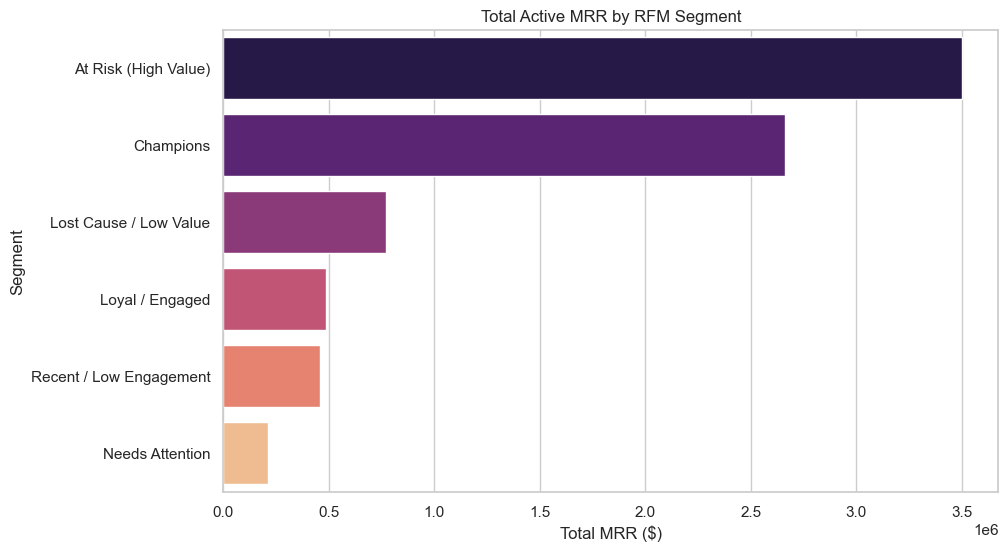

,Segment,Customer_Count,Total_MRR,Avg_MRR
0,At Risk (High Value),114,3499788,30699.894737
1,Champions,81,2664270,32892.222222
2,Lost Cause / Low Value,87,769451,8844.264368
3,Loyal / Engaged,42,484080,11525.714286
4,Needs Attention,21,211642,10078.190476
5,Recent / Low Engagement,45,457224,10160.533333


In [10]:
segment_rev = rfm_df.groupby('Segment').agg(
    Customer_Count=('account_id', 'count'),
    Total_MRR=('monetary', 'sum'),
    Avg_MRR=('monetary', 'mean')
).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=segment_rev.sort_values('Total_MRR', ascending=False), y='Segment', x='Total_MRR', palette='magma')
plt.title('Total Active MRR by RFM Segment')
plt.xlabel('Total MRR ($)')
plt.ylabel('Segment')
plt.show()

display(segment_rev)

# 12. RFM & Product Engagement
Observing the raw usage values associated with the segments.

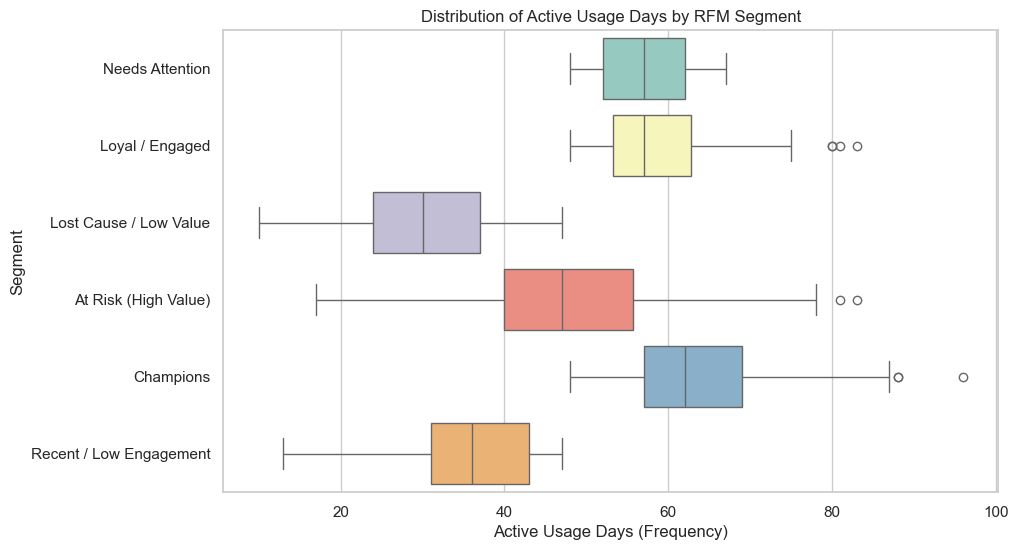

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=rfm_df, y='Segment', x='frequency', palette='Set3')
plt.title('Distribution of Active Usage Days by RFM Segment')
plt.xlabel('Active Usage Days (Frequency)')
plt.ylabel('Segment')
plt.show()

# 13. RFM & Support Burden
Does a specific RFM profile drive disproportionate support tickets?

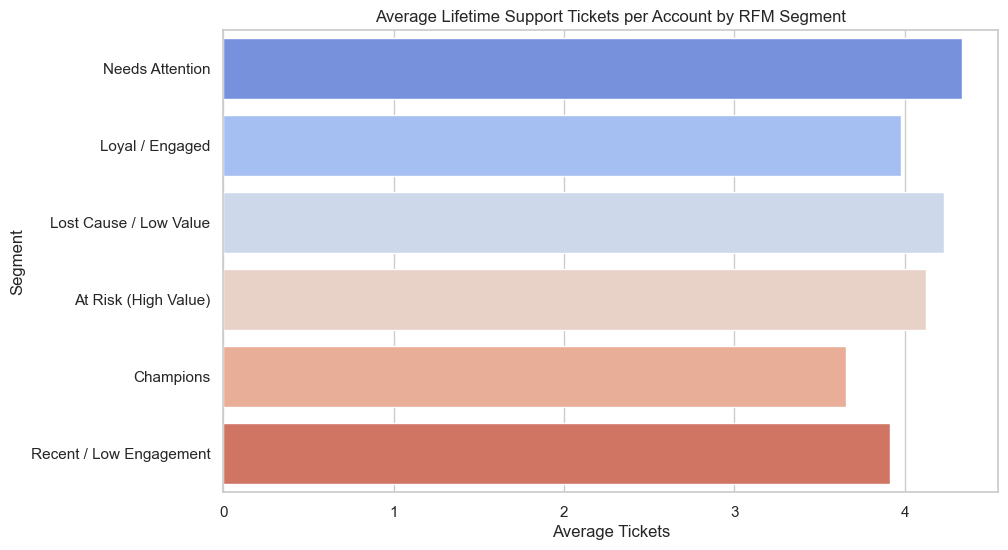

In [12]:
support_agg = support_tickets_df.groupby('account_id').agg(
    total_tickets=('ticket_id', 'count'),
    avg_csat=('satisfaction_score', 'mean')
).reset_index()

rfm_support = rfm_df.merge(support_agg, on='account_id', how='left').fillna({'total_tickets': 0})

plt.figure(figsize=(10, 6))
sns.barplot(data=rfm_support, y='Segment', x='total_tickets', estimator=np.mean, ci=None, palette='coolwarm')
plt.title('Average Lifetime Support Tickets per Account by RFM Segment')
plt.xlabel('Average Tickets')
plt.ylabel('Segment')
plt.show()

# 14. RFM & Plan Tier
Do Enterprise accounts automatically become Champions, or is there segment diversity within plans?

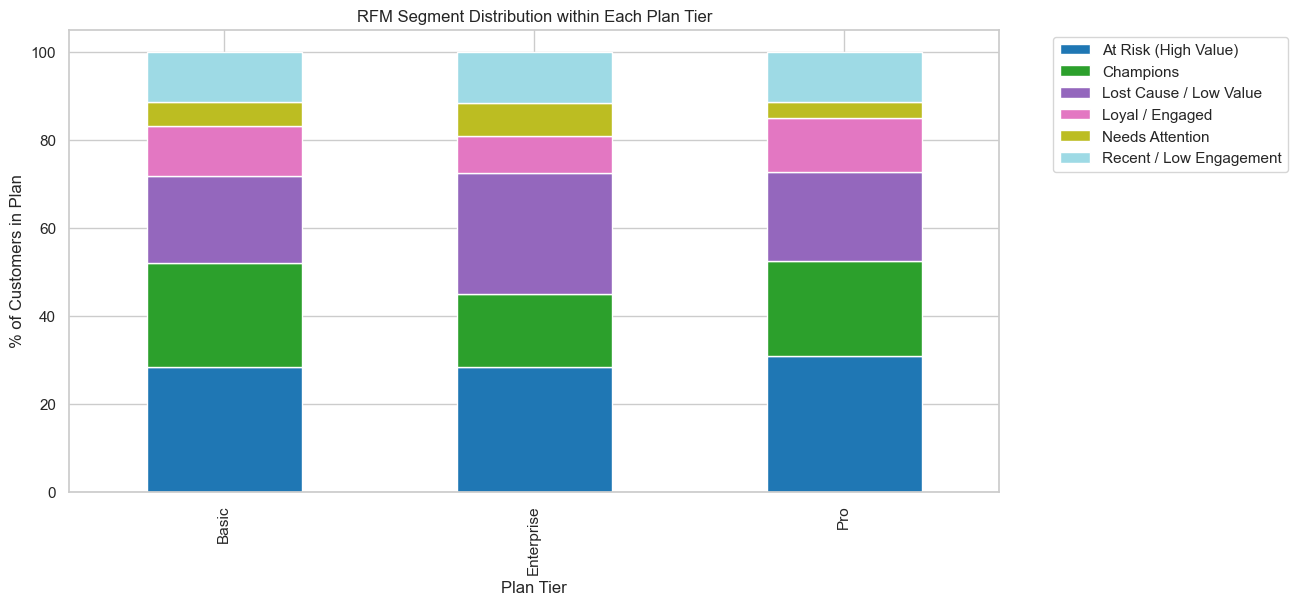

In [13]:
plan_segment = rfm_df.groupby(['plan_tier', 'Segment']).size().unstack(fill_value=0)
plan_segment_pct = plan_segment.div(plan_segment.sum(axis=1), axis=0) * 100

plan_segment_pct.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20')
plt.title('RFM Segment Distribution within Each Plan Tier')
plt.xlabel('Plan Tier')
plt.ylabel('% of Customers in Plan')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 15. Retention Priority Targets
Isolating the explicitly at-risk high MRR clients.

In [14]:
retention_targets = rfm_df[rfm_df['Segment'] == 'At Risk (High Value)'].sort_values('monetary', ascending=False)
print(f"Total MRR categorized as 'At Risk (High Value)': ${retention_targets['monetary'].sum():,.2f}")
display(retention_targets[['account_id', 'industry', 'plan_tier', 'recency', 'frequency', 'monetary', 'RFM_Concat']].head(10))

Total MRR categorized as 'At Risk (High Value)': $3,499,788.00


,account_id,industry,plan_tier,recency,frequency,monetary,RFM_Concat
308,A-d4e0d4,Fintech,Basic,27,47,114777,124
96,A-5c046d,Edtech,Basic,14,44,83886,224
380,A-18793f,Edtech,Basic,19,46,75776,224
374,A-c58f49,Edtech,Enterprise,22,36,70980,224
130,A-fa3095,Fintech,Basic,16,55,69230,234
369,A-e08cd3,Fintech,Pro,1,43,67737,424
175,A-40906c,Edtech,Basic,28,59,64400,134
133,A-56962b,Edtech,Enterprise,41,28,54605,114
67,A-66224b,Healthtech,Pro,27,59,50876,134
134,A-e60f9d,Fintech,Basic,63,62,50095,144


# 16. Expansion Opportunity Analysis
Identifying active clients ('Loyal / Engaged') on lower plan tiers who might be candidates for an upsell because they heavily rely on the product (High F and R) but currently pay very little (Low M).

In [15]:
upsell_targets = rfm_df[(rfm_df['Segment'] == 'Loyal / Engaged') & (rfm_df['plan_tier'] == 'Standard')]
print(f"Found {len(upsell_targets)} highly engaged Standard-tier accounts representing potential upsell opportunities.")
display(upsell_targets[['account_id', 'recency', 'frequency', 'monetary']].head(5))

Found 0 highly engaged Standard-tier accounts representing potential upsell opportunities.


,account_id,recency,frequency,monetary


# 17. RFM Segment Matrix
Visualizing the scatter of Frequency vs Recency, color-coded by our descriptive segments.

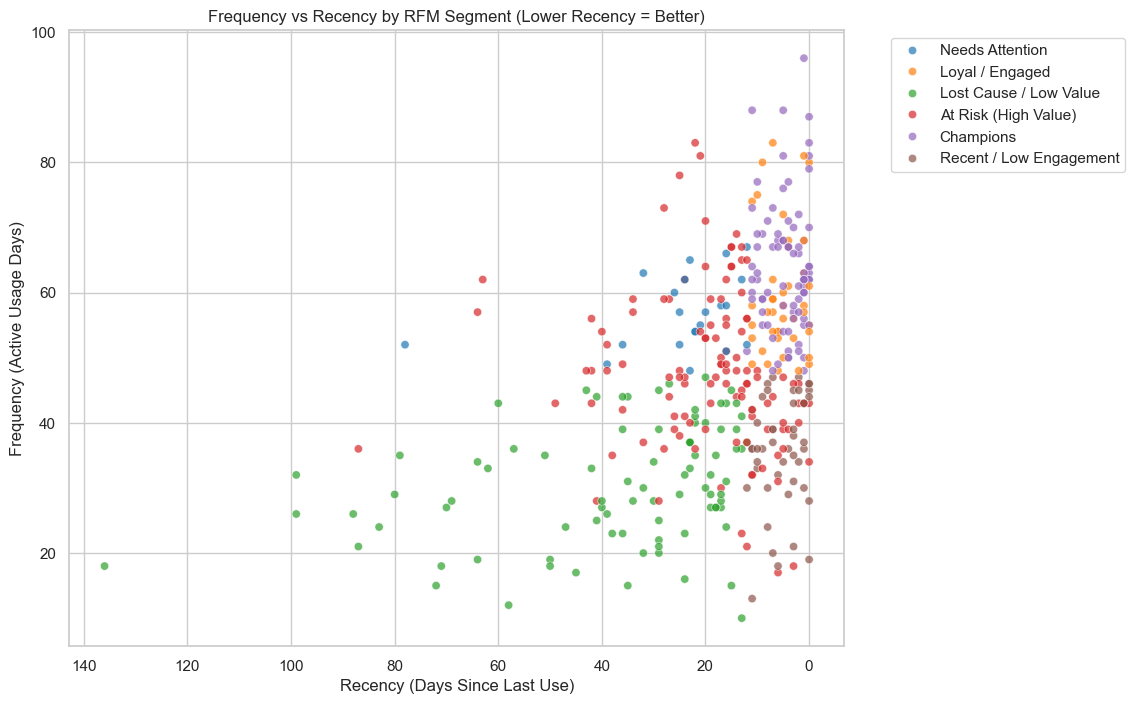

In [16]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=rfm_df, x='recency', y='frequency', hue='Segment', palette='tab10', alpha=0.7)
plt.title('Frequency vs Recency by RFM Segment (Lower Recency = Better)')
plt.xlabel('Recency (Days Since Last Use)')
plt.ylabel('Frequency (Active Usage Days)')
plt.gca().invert_xaxis() # Invert x-axis so 'Recent' is on the right
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 18. RFM Visualizations (Rendered Inline)

# 19. RFM Findings

| ID | Area | Observation | Evidence | Business Impact | Recommended Action |
|----|------|-------------|----------|-----------------|--------------------|
| 1 | Revenue | A small subset of "Champions" drives a vastly disproportionate share of total active MRR | Segment Revenue Barplot | High revenue concentration | Implement "white-glove" VIP CS models for Champions |
| 2 | Risk | Substantial MRR sits in the "At Risk (High Value)" segment, characterized by high MRR but fading recency/frequency | Retention Targets Table | Vulnerable baseline revenue | Launch immediate health checks on Enterprise accounts fading in usage |
| 3 | Expansion | Numerous Standard accounts exhibit "Champion-like" usage frequency but low MRR | Upsell Targets Filter | Uncaptured product value | Deploy targeted upgrade campaigns to highly engaged Standard users |
| 4 | Product | Enterprise plans contain significant internal segment diversity (not all Enterprise are Champions) | Plan Tier Distribution | False security in high-MRR deals | Do not rely purely on plan tier to estimate account health; monitor RFM closely |

# 20. Business Recommendations

### Retention Priorities
Consider prioritizing direct outreach to accounts falling into the `At Risk (High Value)` segment. Their high monetary value makes them critical to preserve, but their declining usage metrics (poor Recency/Frequency) flag them as statistically distant from the product.

### Expansion Opportunities
Investigate the usage patterns of the `Loyal / Engaged` segment on Standard tiers. These accounts extract maximum utility from the platform and are prime candidates for testing feature-gated upgrade campaigns.

### Customer Success
Test mapping support resources to the `Champions` segment to ensure our most valuable and engaged customers experience zero friction, while standardizing automated outreach for `Needs Attention` accounts.

# 21. Limitations

- **Monetary Definition**: Because there is no historical invoice ledger, Monetary (M) is strictly defined as Current MRR rather than Lifetime Transaction Value (which is traditionally used in e-commerce).
- **Descriptive Segmentation**: This RFM matrix is a descriptive heuristic based on quartile thresholds. It is **not** a predictive machine learning model. An account labeled "At Risk" is statistically drifting in usage, but it does not guarantee churn.
- **No Causality**: This notebook observes overlaps (e.g., Champions logging more support tickets). It does not prove that logging support tickets causes an account to become a Champion.
- **Exclusion of Churned Accounts**: RFM was calculated strictly for currently active accounts to drive actionable CS targeting. Historical churned accounts were excluded from the scoring model.

# 22. Next Analysis

- `12_statistical_analysis.ipynb`: Transition from descriptive segmentations (like RFM and Cohorts) into formal statistical hypothesis testing (e.g., T-Tests, Chi-Square) to rigorously validate if these observed segment differences are statistically significant.